In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# <a target="_blank" href="https://colab.research.google.com/github/facebookresearch/sam3/blob/main/notebooks/sam3_image_interactive.ipynb">
#   <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
# </a>

In [2]:
using_colab = False # 设置是否在 Google Colab 环境下运行。本地运行时设为 False。


In [3]:
if using_colab: # 如果是在 Colab 环境，则执行以下环境配置
    import torch # 导入核心深度学习框架 PyTorch
    import torchvision # 导入配套的计算机视觉库
    print("PyTorch version:", torch.__version__) # 打印当前 PyTorch 版本
    print("Torchvision version:", torchvision.__version__) # 打印当前 Torchvision 版本
    print("CUDA is available:", torch.cuda.is_available()) # 检查 GPU 是否可用
    import sys
    # 使用 pip 安装必要的扩展库：OpenCV (图像处理), Matplotlib (绘图), Scikit-Learn (机器学习工具)
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
    # 从 GitHub 仓库安装最新的 SAM3 源代码
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'


In [4]:
%matplotlib widget # 启用 Jupyter 的交互式绘图后端，支持缩放和鼠标事件交互


In [5]:
import torch # 导入 PyTorch 库
# 在 Ampere 架构（如 A100, RTX 30系列）及更高版本的 GPU 上启用 TensorFloat-32 (TF32) 以加速矩阵运算
# 详情参考：https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True # 允许矩阵乘法使用 TF32 加速
torch.backends.cudnn.allow_tf32 = True # 允许 cuDNN 使用 TF32 加速

# 全局启用自动混合精度 (Autocast)，默认使用 bfloat16。如果显卡不支持，可尝试改为 float16。
# 这可以在保持精度的同时减少显存占用并提高推理速度。
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

# 全局开启推理模式 (Inference Mode)，禁用梯度计算以节省显存。如果需要训练模型才需关闭。
torch.inference_mode().__enter__()


# Load the model

In [6]:
import sam3 # 导入 sam3 核心包
from sam3 import build_sam3_image_model # 导入构建图像模型的工厂函数
import os
sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..") # 定位 sam3 库的根目录位置
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz" # 指定文本编码词汇表（BPE）的路径，用于处理文本提示词


In [7]:
import sam3 # 导入 sam3 核心包
from sam3 import build_sam3_image_model # 导入构建图像模型的工厂函数
import os
sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..") # 定位 sam3 库的根目录位置
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz" # 指定文本编码词汇表（BPE）的路径，用于处理文本提示词


In [8]:
from sam3.model.sam3_image_processor import Sam3Processor # 导入推理处理器类
# Sam3Processor 是核心处理类，负责图像预处理、提示编码和掩码解码。它是连接模型和 UI 的桥梁。
processor = Sam3Processor(model) # 创建处理器实例，并注入刚刚构建的模型


# Jupyter widget

**中文解析：** 这是基于 Jupyter 的交互小部件，展示了如何通过回调函数实时调用模型推理。

In [9]:
import io
import ipywidgets as widgets # 导入 Jupyter 交互小部件库
import matplotlib.pyplot as plt # 导入绘图库
import numpy as np # 导入数值计算库
import PIL.Image # 导入图像处理库
import requests # 导入 HTTP 请求库用于加载图片 URL
from IPython.display import clear_output, display, HTML # 用于在 Jupyter 中显示组件
from matplotlib.patches import Rectangle # 用于在图上绘制提示框

class Sam3SegmentationWidget:
    """Interactive Jupyter widget for SAM3 segmentation with text and box prompts."""
    # (用于 SAM3 文本和框选分割的交互式 Jupyter 小部件)

    def __init__(self, processor):
        """
        Initialize the segmentation widget. (初始化分割小部件)

        Args:
            processor: Sam3Processor instance (SAM3 处理器实例)
        """
        self.processor = processor # 存储传入的处理器
        self.state = None # 推理状态变量，初始化为空
        self.current_image = None # 当前 PIL 图像对象
        self.current_image_array = None # 当前图像的 Numpy 数组格式
        self.box_mode = "positive" # 框选模式：positive (正向) 或 negative (反向)
        self.drawing_box = False # 标记是否正在绘制框
        self.box_start = None # 存储框的起始坐标
        self.current_rect = None # 存储当前 Matplotlib 矩形对象

        self._setup_ui() # 调用方法设置用户界面组件
        self._setup_plot() # 调用方法设置 Matplotlib 图表

    def _setup_ui(self):
        """Set up the UI components. (设置 UI 组件)"""
        # 创建文件上传小部件
        self.upload_widget = widgets.FileUpload(
            accept="image/*", multiple=False, description="Upload Image"
        )
        # 监听上传值的变化，上传新文件时回调 _on_image_upload
        self.upload_widget.observe(self._on_image_upload, names="value")

        # 创建 URL 输入文本框
        self.url_input = widgets.Text(
            placeholder="Or enter image URL",
        )
        # 创建加载 URL 的按钮
        self.url_button = widgets.Button(description="Load URL", button_style="info")
        # 设置点击按钮时的回调函数
        self.url_button.on_click(self._on_load_url)
        # 使用水平布局 (HBox) 组合文本框和按钮
        url_box = widgets.HBox(
            [self.url_input, self.url_button],
            layout=widgets.Layout(width="100%", justify_content="space-between"),
        )

        # 创建文本提示词输入框
        self.text_input = widgets.Text(
            placeholder='Enter segmentation prompt (e.g., "person", "dog")',
            continuous_update=False, # 仅在回车或失去焦点时更新输入
        )
        # 监听文本输入变化 (通常是敲回车触发)
        self.text_input.observe(self._on_text_submit, names="value")
        # 创建分割按钮
        self.text_button = widgets.Button(description="Segment", button_style="success")
        # 设置按钮点击回调
        self.text_button.on_click(self._on_text_prompt)
        # 水平组合文本输入和分割按钮
        text_box = widgets.HBox(
            [self.text_input, self.text_button],
            layout=widgets.Layout(width="100%", justify_content="space-between"),
        )

        # 创建切换按钮，用于选择正向框或反向框
        self.box_mode_buttons = widgets.ToggleButtons(
            options=["Positive Boxes", "Negative Boxes"],
            description="Box Mode:",
            button_style="",
            tooltips=[
                "Draw boxes around objects to include (框选要包含的对象)",
                "Draw boxes around objects to exclude (框选要排除的对象)",
            ],
        )
        # 监听切换按钮的状态变化
        self.box_mode_buttons.observe(self._on_box_mode_change, names="value")

        # 创建清除所有提示的按钮
        self.clear_button = widgets.Button(
            description="Clear All Prompts", button_style="warning"
        )
        # 点击即清除所有已有的提示词和框
        self.clear_button.on_click(self._on_clear_prompts)

        # 创建置信度滑动条
        self.confidence_slider = widgets.FloatSlider(
            value=0.5, # 默认值 0.5
            min=0.0,
            max=1.0,
            step=0.01,
            description="Confidence:",
            continuous_update=False, # 停止滑动后才更新
            style={"description_width": "initial"},
        )
        # 监听置信度数值变化
        self.confidence_slider.observe(self._on_confidence_change, names="value")

        # 创建图像显示尺寸滑动条
        self.size_slider = widgets.IntSlider(
            value=960, # 默认显示宽度 960 像素
            min=300,
            max=2000,
            step=10,
            description="Image Size:",
            continuous_update=False,
            style={"description_width": "initial"},
        )
        # 监听尺寸变化以动态调整显示
        self.size_slider.observe(self._on_size_change, names="value")

        # 放置滑动条的水平容器
        slider_box = widgets.HBox(
            [self.confidence_slider, self.size_slider],
            layout=widgets.Layout(justify_content="space-between"),
        )

        # 输出小部件，用于容纳图片绘图
        self.output = widgets.Output()
        # 状态标签，用于显示各种操作状态或错误信息
        self.status_label = widgets.Label(value="Upload an image to begin")

        # 包装绘图输出的容器，并添加 CSS 类名以供样式控制
        self.plot_container = widgets.Box([self.output])
        self.plot_container.add_class("no-drag")

        # 定义嵌入式 CSS 样式，将鼠标在画布上的指针改为十字准星
        css_style = widgets.HTML(
            """
        <style>
            .jupyter-matplotlib-canvas, canvas {
                cursor: crosshair !important;
            }
        </style>
        """
        )
        # 定义折叠面板的图片源页面内容
        source_pane = widgets.VBox([self.upload_widget, url_box])
        # 定义折叠面板的分割提示页面内容
        prompt_pane = widgets.VBox(
            [
                widgets.Label("Text Prompt:"),
                text_box,
                self.box_mode_buttons,
                self.confidence_slider,
                self.clear_button,
            ]
        )
        # 定义折叠面板的显示设置页面内容
        display_pane = widgets.VBox([self.size_slider])

        # 创建包含上述三个页签的折叠面板 (Accordion)
        self.accordion = widgets.Accordion(
            children=[source_pane, prompt_pane, display_pane]
        )
        # 设置每个页签的显示名称
        self.accordion.set_title(0, "Image Source")
        self.accordion.set_title(1, "Segmentation Prompts")
        self.accordion.set_title(2, "Display Settings")
        self.accordion.selected_index = 0  # 默认展示第一个页签

        # 创建整个应用的左侧边栏，包含状态条、标题和折叠面板
        sidebar = widgets.VBox(
            [self.status_label, widgets.HTML("<h4>Controls</h4>"), self.accordion]
        )
        # 设定边栏的精细 CSS 布局
        sidebar.layout = widgets.Layout(
            width="380px",
            min_width="380px",
            max_width="380px",
            border="1px solid #e0e0e0",
            padding="10px",
            margin="0 15px 0 0",
            flex="0 0 auto",
        )

        # 创建右侧主工作区容器
        main_area = widgets.VBox([self.plot_container])
        main_area.layout = widgets.Layout(flex="1", min_width="500px", overflow="auto")

        # 将左侧边栏和右侧主工作区拼接到一起
        app_layout = widgets.HBox([sidebar, main_area])
        app_layout.layout = widgets.Layout(
            width="100%",
            display="flex",
            flex_flow="row",
            align_items="stretch",
        )

        # 最终应用的主容器
        self.container = widgets.VBox(
            [
                css_style, # 应用自定义 CSS
                widgets.HTML("<h3>🖼️ SAM3 Interactive Segmentation</h3>"),
                app_layout,
            ]
        )

    def _setup_plot(self):
        """Set up the matplotlib figure. (设置 Matplotlib 图表)"""
        # 创建子图对象
        self.fig, self.ax = plt.subplots(figsize=(12, 8))
        # 隐藏坐标轴刻度和边线
        self.ax.axis("off")
        # 调整布局使内容填充整个画布区域
        self.fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        # 隐藏 Matplotlib 默认工具栏
        self.fig.canvas.toolbar_visible = False
        self.fig.canvas.header_visible = False
        self.fig.canvas.footer_visible = False
        self.fig.canvas.resizable = False

    def _set_loading(self, is_loading, message="Processing..."):
        """Show/hide loading state and disable/enable controls. (显示/隐藏加载状态，并禁用/启用控制组件)"""
        if is_loading:
            # 加载中：显示提示文字并冻结所有按钮和输入框
            self.status_label.value = f"⏳ {message}"
            self.upload_widget.disabled = True
            self.url_button.disabled = True
            self.text_button.disabled = True
            self.clear_button.disabled = True
            self.box_mode_buttons.disabled = True
            self.confidence_slider.disabled = True
        else:
            # 加载完毕：恢复所有控制组件的可交互性
            self.upload_widget.disabled = False
            self.url_button.disabled = False
            self.text_button.disabled = False
            self.clear_button.disabled = False
            self.box_mode_buttons.disabled = False
            self.confidence_slider.disabled = False

    def _on_image_upload(self, change):
        """Handle image upload. (处理图片上传)"""
        if change["new"]:
            # 获取上传的文件列表中的第一个文件
            uploaded_file = change["new"][0]
            # 使用 PIL 打开上传的内容流，并转换为 RGB 格式
            image = PIL.Image.open(io.BytesIO(uploaded_file["content"])).convert("RGB")
            # 将图片同步到模型处理器并更新显示
            self._set_image(image)

    def _on_load_url(self, button):
        """Handle loading image from URL. (处理从 URL 加载图片)"""
        url = self.url_input.value.strip()
        if not url:
            self.status_label.value = "Please enter a URL"
            return

        # 开始下载
        self._set_loading(True, "Downloading image from URL...")

        try:
            # 抓取网络图片
            response = requests.get(url, timeout=10)
            response.raise_for_status() # 检查 HTTP 状态码
            # 转为 PIL 对象
            image = PIL.Image.open(io.BytesIO(response.content)).convert("RGB")
            # 同步图片数据
            self._set_image(image)
        except Exception as e:
            self._set_loading(False)
            self.status_label.value = f"Error loading image: {str(e)}"

    def _set_image(self, image):
        """Set the current image, adjust figure size, and initialize state. (设置当前图片，调整图像大小并初始化推理状态)"""
        self._set_loading(True, "Processing image through model...")

        try:
            self.current_image = image # 缓存图像对象
            self.current_image_array = np.array(image) # 转为 Numpy 用于后续显示
            # *** 重要：运行主干网络提取全局图像特征（这一步最耗时）***
            self.state = self.processor.set_image(image)
            self._set_loading(False)
            self.status_label.value = (
                f"Image loaded: {image.size[0]}x{image.size[1]} pixels"
            )
            self._resize_figure() # 调整 Matplotlib 尺寸以适应新图
            self._update_display() # 绘制底图
            self._connect_plot_events() # 连接鼠标交互事件
            self.accordion.selected_index = 1 # 自动展开“分割提示”页签
        except Exception as e:
            self._set_loading(False)
            self.status_label.value = f"Error processing image: {str(e)}"

    def _on_text_submit(self, change):
        """Handle text prompt submission via Enter key. (处理通过回车键提交文本提示词)"""
        # 与点击“Segment”按钮调用相同逻辑
        self._on_text_prompt(None)

    def _on_text_prompt(self, button):
        """Handle text prompt submission. (处理文本提示词提交)"""
        if self.state is None:
            self.status_label.value = "Please load an image first"
            return

        prompt = self.text_input.value.strip()
        if not prompt:
            self.status_label.value = "Please enter a prompt"
            return

        self._set_loading(True, f'Segmenting with prompt: "{prompt}"...')

        try:
            # *** 基于缓存的特征提取运行文本提示词编码和掩码解码 ***
            self.state = self.processor.set_text_prompt(prompt, self.state)
            self._set_loading(False)
            self.status_label.value = f'Segmented with prompt: "{prompt}"'
            self._update_display() # 渲染分割结果
        except Exception as e:
            self._set_loading(False)
            self.status_label.value = f"Error: {str(e)}"

    def _on_box_mode_change(self, change):
        """Handle box mode toggle. (处理框选模式（Box Mode）切换)"""
        # 更新当前是正向标注还是反向标注
        self.box_mode = "positive" if change["new"] == "Positive Boxes" else "negative"

    def _on_clear_prompts(self, button):
        """Clear all prompts and reset to image only. (清除所有提示词并重置为仅显示图片)"""
        if self.current_image is not None:
            try:
                self._set_loading(True, "Clearing prompts and resetting...")
                # 调用模型端重置逻辑
                self.state = self.processor.reset_all_prompts(self.state)
                # 清理 UI 端的自定义存储项
                if "prompted_boxes" in self.state:
                    del self.state["prompted_boxes"]
                self.text_input.value = ""
                self._set_loading(False)
                self.status_label.value = "Cleared all prompts"
                self._update_display() # 重新刷新显示背景图
            except Exception as e:
                self._set_loading(False)
                import traceback
                self.status_label.value = f"Error: {str(e)} {traceback.format_exc()}"

    def _on_confidence_change(self, change):
        """Handle confidence threshold change. (处理置信度阈值变更)"""
        if self.state is not None:
            # 手动调整阈值会过滤现有掩码而无需重新运行推理
            self.state = self.processor.set_confidence_threshold(
                change["new"], self.state
            )
            self._update_display()

    def _connect_plot_events(self):
        """Connect matplotlib event handlers for box drawing. (连接 Matplotlib 事件处理程序以实现框画识别)"""
        # 禁用 Matplotlib 默认工具栏的平移导航，以免冲突
        if hasattr(self.fig.canvas, "toolbar") and self.fig.canvas.toolbar is not None:
            self.fig.canvas.toolbar.pan()
            self.fig.canvas.toolbar.pan()

        # 连接鼠标按下、移动、释放三个核心交互事件
        self.fig.canvas.mpl_connect("button_press_event", self._on_press)
        self.fig.canvas.mpl_connect("button_release_event", self._on_release)
        self.fig.canvas.mpl_connect("motion_notify_event", self._on_motion)

    def _on_press(self, event):
        """Handle mouse press for box drawing. (处理鼠标按下事件以开始绘制框)"""
        # 如果点击位置不在坐标轴内，直接返回
        if event.inaxes != self.ax:
            return
        self.drawing_box = True # 开启绘图开关
        self.box_start = (event.xdata, event.ydata) # 记录按下时的起始坐标

    def _on_motion(self, event):
        """Handle mouse motion for box preview. (处理鼠标移动事件以预览绘制框)"""
        # 如果未在绘图状态或坐标轴外，则不响应
        if not self.drawing_box or event.inaxes != self.ax or self.box_start is None:
            return

        # 如果之前已经在画框，先移除上一次移动产生的预览框
        if self.current_rect is not None:
            self.current_rect.remove()

        x0, y0 = self.box_start
        x1, y1 = event.xdata, event.ydata
        width = x1 - x0
        height = y1 - y0

        # 根据当前模式决定框的颜色
        color = "green" if self.box_mode == "positive" else "red"
        # 创建一个新的装饰性矩形（不带填充，虚线边框）
        self.current_rect = Rectangle(
            (x0, y0),
            width,
            height,
            fill=False,
            edgecolor=color,
            linewidth=2,
            linestyle="--",
        )
        self.ax.add_patch(self.current_rect)
        self.fig.canvas.draw_idle() # 请求重绘画布

    def _on_release(self, event):
        """Handle mouse release to finalize box. (处理鼠标释放事件以最终确认框)"""
        if not self.drawing_box or event.inaxes != self.ax or self.box_start is None:
            self.drawing_box = False
            return

        self.drawing_box = False # 结束绘图状态

        # 移除预览框对象
        if self.current_rect is not None:
            self.current_rect.remove()
            self.current_rect = None

        if self.state is None:
            return

        # 计算矩形框的四个边值
        x0, y0 = self.box_start
        x1, y1 = event.xdata, event.ydata

        x_min = min(x0, x1)
        x_max = max(x0, x1)
        y_min = min(y0, y1)
        y_max = max(y0, y1)

        # 如果画的框太小（小于 5 像素），则忽略（防止误触）
        if abs(x_max - x_min) < 5 or abs(y_max - y_min) < 5:
            return

        # 获取原始图像尺寸用于归一化
        img_h = self.state["original_height"]
        img_w = self.state["original_width"]

        # 坐标转换：从像素坐标转换为模型需要的 [cx, cy, w, h] 归一化格式 (范围 0-1)
        center_x = (x_min + x_max) / 2.0 / img_w
        center_y = (y_min + y_max) / 2.0 / img_h
        width = (x_max - x_min) / img_w
        height = (y_max - y_min) / img_h

        box = [center_x, center_y, width, height]
        label = self.box_mode == "positive"
        mode_str = "positive" if label else "negative"

        # 在推理状态中追加存储这个提示框位置信息（用于后期渲染）
        if "prompted_boxes" not in self.state:
            self.state["prompted_boxes"] = []
        self.state["prompted_boxes"].append(
            {"box": [x_min, y_min, x_max, y_max], "label": label}
        )

        self._set_loading(True, f"Adding {mode_str} box and re-segmenting...")

        try:
            # *** 重要：将几何框提示注入推理器并获取更新后的分割状态 ***
            self.state = self.processor.add_geometric_prompt(box, label, self.state)
            self._set_loading(False)
            self.status_label.value = f"Added {mode_str} box"
            self._update_display() # 更新绘图显示
        except Exception as e:
            self._set_loading(False)
            self.status_label.value = f"Error adding box: {str(e)}"

    def _resize_figure(self):
        """Calculate and apply new figure size based on image and slider value. (根据图像和滑块值计算并应用新的图像尺寸)"""
        if self.current_image is None:
            return

        # 1. 获取原始图像尺寸
        img_w, img_h = self.current_image.size

        # 2. 从滑块中获取目标显示宽度
        display_w = float(self.size_slider.value)

        # 3. 按照原始比例计算对应的目标高度
        aspect_ratio = img_h / img_w
        display_h = int(display_w * aspect_ratio)

        # 4. 将像素尺寸转换为 Matplotlib 使用的英寸单位 (DPI)
        dpi = self.fig.dpi
        new_figsize = (display_w / dpi, display_h / dpi)
        self.fig.set_size_inches(new_figsize, forward=True)

    def _on_size_change(self, change):
        """Handle a change from the image size slider. (处理图像尺寸滑块的变更)"""
        if self.current_image is not None:
            self._resize_figure() # 更新全局比例
            self._update_display() # 重新渲染已缩放的内容

    def _update_display(self):
        """Update the display with current results. (使用当前结果更新显示界面)"""
        if self.current_image_array is None:
            return

        # 在指定的输出小部件中进行绘图，wait=True 表示立即清理旧的输出
        with self.output:
            clear_output(wait=True)

            self.ax.clear() # 清空坐标轴上的所有元素
            self.ax.axis("off") # 强制隐藏坐标轴装饰
            self.ax.imshow(self.current_image_array) # 绘制底图（背景照片）

            # 渲染已检测到的掩码
            if self.state is not None and "masks" in self.state:
                masks = self.state.get("masks", [])
                boxes = self.state.get("boxes", []) # 每个实例的对应包围框
                scores = self.state.get("scores", []) # 每个实例的置信度分数

                if len(masks) > 0:
                    # 创建一个空的透明覆盖层 (RGBA)
                    mask_overlay = np.zeros((*self.current_image_array.shape[:2], 4))

                    for i, (mask, box, score) in enumerate(zip(masks, boxes, scores)):
                        # 提取单掩码数组并移动到 CPU
                        mask_np = mask[0].cpu().numpy()

                        # 根据序号循环选择一种鲜艳的颜色
                        color = plt.cm.tab10(i % 10)[:3]
                        # 在掩码对应的像素位置涂上颜色，设置 alpha 为 0.5 半透明
                        mask_overlay[mask_np > 0.5] = (*color, 0.5)

                        # 渲染该实例的检测包围框
                        x0, y0, x1, y1 = box.cpu().numpy()
                        rect = Rectangle(
                            (x0, y0),
                            x1 - x0,
                            y1 - y0,
                            fill=False,
                            edgecolor=color,
                            linewidth=2,
                        )
                        self.ax.add_patch(rect)

                        # 渲染置信度文本标签
                        self.ax.text(
                            x0,
                            y0 - 5,
                            f"{score:.2f}",
                            color="white",
                            fontsize=10,
                            bbox=dict(
                                facecolor=color, alpha=0.7, edgecolor="none", pad=2
                            ),
                        )

                    # 将掩码覆盖层叠加到底图之上
                    self.ax.imshow(mask_overlay)
                    self.status_label.value = f"Found {len(masks)} object(s)"
                else:
                    self.status_label.value = (
                        "No objects found above confidence threshold"
                    )

            # 渲染用户刚才手动画的虚线提示框 (prompted boxes)
            if self.state is not None and "prompted_boxes" in self.state:
                for prompted_box in self.state["prompted_boxes"]:
                    box_coords = prompted_box["box"]
                    is_positive = prompted_box["label"]

                    x0, y0, x1, y1 = box_coords
                    color = "green" if is_positive else "red"

                    rect = Rectangle(
                        (x0, y0),
                        x1 - x0,
                        y1 - y0,
                        fill=False,
                        edgecolor=color,
                        linewidth=2,
                        linestyle="--",
                    )
                    self.ax.add_patch(rect)

    def display(self):
        # 显示整个 VBox 布局容器
        display(self.container)

    # 此方法允许直接把 widget 对象放在 Cell 最后一行来展示
    def _ipython_display_(self):
        self.display()


# Run!

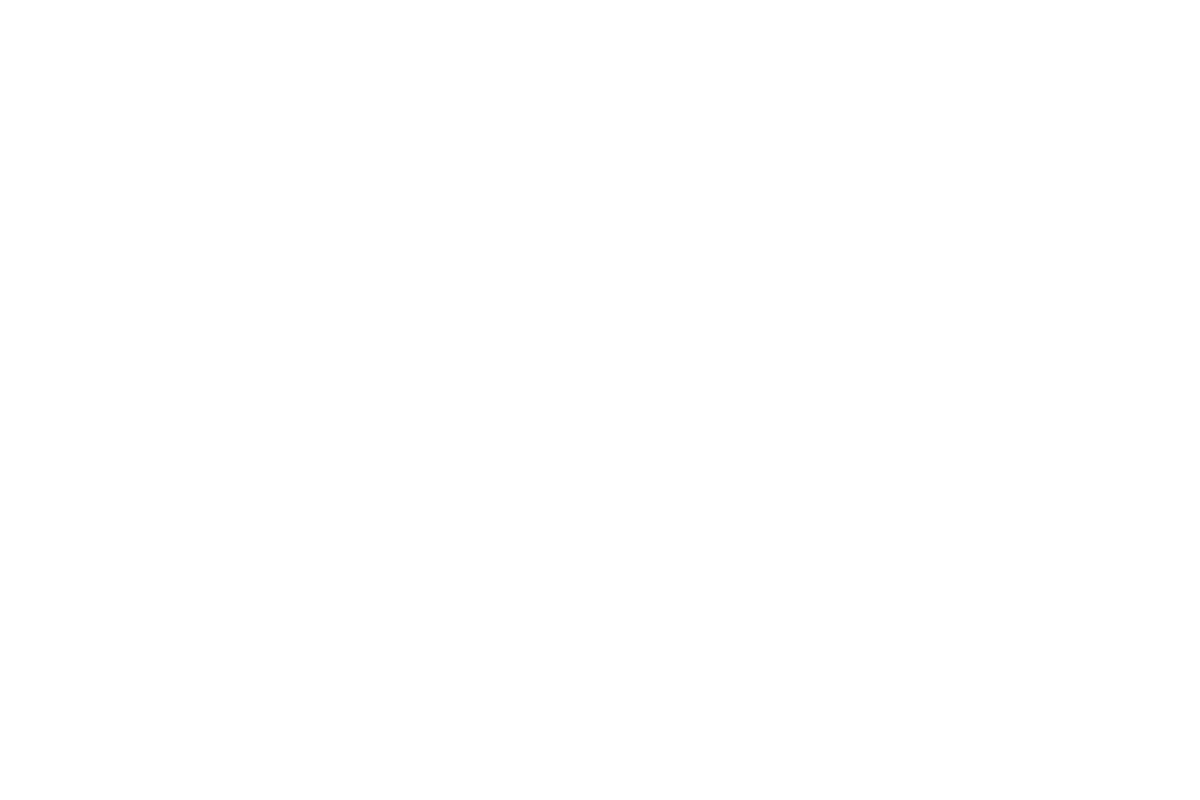

In [10]:
widget = Sam3SegmentationWidget(processor) # 实例化交互式小部件，并将处理器传入
widget.display() # 在 Jupyter 单元格中渲染整个交互界面
